In [1]:
import pandas as pd

df = pd.read_csv("data/Student_Performance.csv")
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


In [3]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278932,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


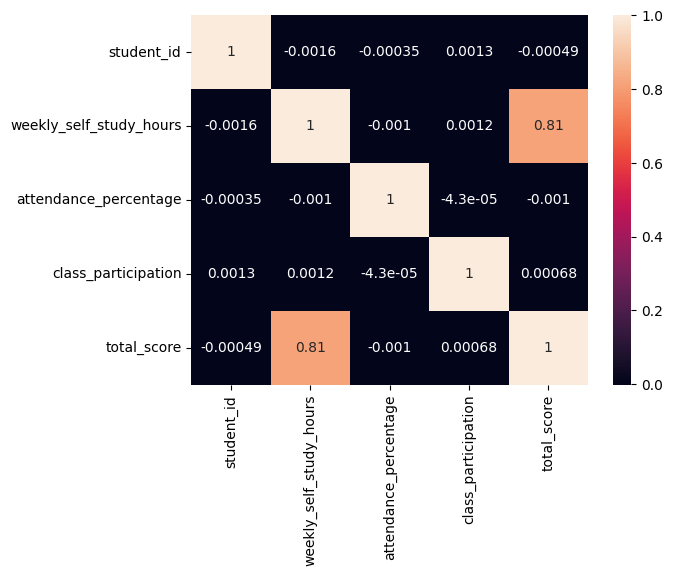

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

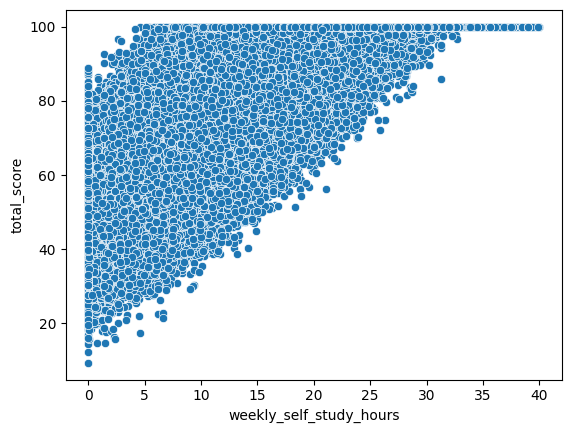

In [5]:
sns.scatterplot(x='weekly_self_study_hours', y='total_score', data=df)
plt.show()

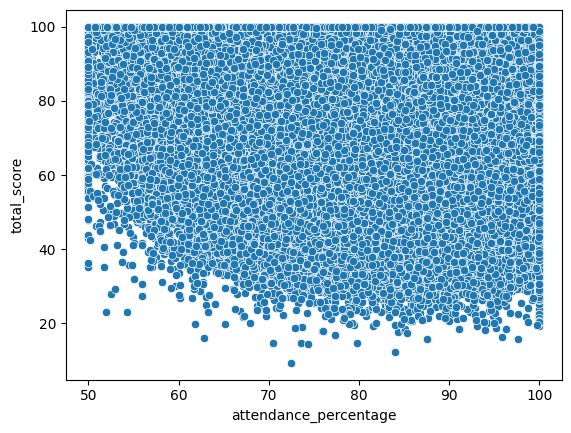

In [6]:
sns.scatterplot(x='attendance_percentage', y='total_score', data=df)
plt.show()

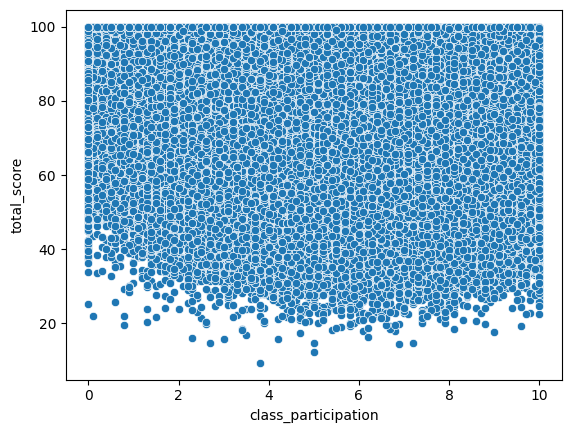

In [7]:
sns.scatterplot(x='class_participation', y='total_score', data=df)
plt.show()

In [8]:
## Insights

- Weekly self-study hours show a strong positive correlation with total score.
- Class participation also significantly impacts performance.
- Attendance has a moderate influence on scores.

SyntaxError: invalid syntax (27753877.py, line 3)

In [9]:
X = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation']]
y = df['total_score']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=20, max_depth=5)
rf.fit(X_train, y_train)

,n_estimators,20
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression
lr_pred = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, lr_pred))

# Random Forest
rf_pred = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, rf_pred))

Linear Regression R2: 0.6600425865640975
Random Forest R2: 0.7175848601855157


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import r2_score
print("Improved Random Forest R2:", r2_score(y_test, rf_pred))

Improved Random Forest R2: 0.7175478748103742


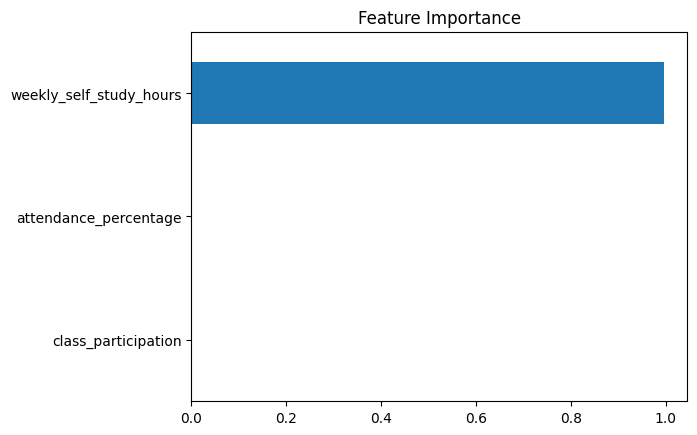

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import joblib

df = pd.read_csv("data/student_performance.csv")

X = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation']]
y = df['total_score']

model = RandomForestRegressor(n_estimators=20, max_depth=5, n_jobs=1, random_state=42)
model.fit(X, y)

joblib.dump(model, "model.pkl")

print("Model saved!")

Model saved!
